Copyright Amazon.com, Inc. or its affiliates. All Rights Reserved. <br>
SPDX-License-Identifier: CC-BY-NC-4.0

# Simple Example (LLM)

This example shows how to prune an LLM, using a pretrained model and dataset from Hugging Face. By nature LLMs are large, so it is not possible to prune them quickly for the purposes of a demo, nor without access to a GPU (or multiple). For this reason, this example shows how to prune a tiny LLM with arbitrary weights. To prune a "real" LLM, you'll need run this code on an instance with an appropriate number of GPUs and memory, for a number of hours or days. The settings that should be changed to get the settings we used in the paper for Mistral-7B are indicated after the # sign, where a change is needed. 

Some aspects of this example are specific to LLMs, such as the loading of the model, preparation of the data, and the evaluation of the model. If your model is not an LLM, `simple_example.ipynb` may be a better starting point. 

## Language model evaluation harness

To run this example, please make sure to install the LM Evaluation Harness first:
```
git clone https://github.com/EleutherAI/lm-evaluation-harness
cd lm-evaluation-harness
pip install -e .
```

### Imports

In [1]:
import sys
import os

# 프로젝트 루트 디렉토리의 절대 경로를 얻습니다
project_root = os.path.abspath(os.path.join(os.getcwd(), '../notebooks'))
# 또는 직접 경로를 지정할 수도 있습니다
# project_root = "/path/to/your/project"

# src 디렉토리를 Python 경로에 추가
if project_root not in sys.path:
    sys.path.insert(0, project_root)

In [2]:
import multiprocessing

import os
import pickle
import time
from collections import defaultdict
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader

from icbs.evaluation import evaluate_model, evaluate_model_tasks
from icbs.loops import prune_loop
from icbs.pruner import Pruner
from icbs.solvers import ConstrainedSASolver
from icbs.util import calc_density, get_log_w_names_step, get_named_weights
from icbs.util_llm import is_llm, load_llm, prep_loader_batch, prepare_llm
from notebooks.util import load_dataset, set_num_threads, set_seed

### Settings

Some settings are chosen specifically so that this notebook can be run in a short time.  In such cases, the settings used for the LLMs in the paper are included after the # symbol.

In [3]:
# Model and dataset
model_name =  "meta-llama/Llama-3.2-1B" # "mistralai/Mistral-7B-v0.1" # "stas/tiny-random-llama-2"
dataset_name = "stas/c4-en-10k"  # "allenai/c4"
dataset_args = {}  # {"streaming": True, "name": "en"}
device = "cuda" if torch.cuda.is_available() else "cpu"

# Pruner parameters
seed = 43
density = 0.3
pruner_num_epochs = 5  # 10
num_steps_per_epoch = 1  # 300
init_method = "magnitude"  # "wanda_per_output"
block_size = 128  # 4096
num_restarts = 1  # 20
min_num_steps_per_layer = 1  # 10
selection_method = "gradient"
calc_hessian_method = "gradient_per_sample"
grad_multiplier = 0.75
ridge_multiplier = 0.001
verbose = 2

# Batch sizes
batch_size_evaluation = 64  # 1
batch_size_pruning = 16
batch_size_calibration = 64  # 128
max_batch_size = 1

# Block settings
block_solver = ConstrainedSASolver(verbose=verbose, num_restarts=num_restarts)
k = block_size // 2
tabu_frac = 0.40
fix_frac_prune = 0.42
fix_frac_keep = 0.35

# Workers, etc.
num_cpus = multiprocessing.cpu_count()
dataloader_args = {
    "num_workers": 4 if torch.cuda.is_available() else 0,
    "pin_memory": False,
}

# Only prune linear layers and do not prune the final layer
keep_layers = (torch.nn.Linear,)
layer_name_to_exclude = "lm_head"

# The loss function
loss_function = nn.CrossEntropyLoss()

# Evaluation
evaluate_model_tasks_args = {
    "tasks": ["hellaswag"],
    # ["boolq", "rte", "hellaswag", "winogrande", "arc_easy", "arc_challenge", "openbookqa"]
    "num_fewshot": 0,  # This is zero-shot evaluation
    "limit": 10,  # None
    "check_integrity": False,
    "use_cache": None,  # Do not cache model responses
    "random_seed": None,  # Do not set random seeds - we handle that already
    "numpy_random_seed": None,
    "torch_random_seed": None,
    "fewshot_random_seed": None,
}

# Set the number of threads and seed the random number generator
set_num_threads(num_cpus)
set_seed(seed)

## Load a model

When running on a machine with multiple GPUs, the print out below this cell will show the distribution of the model across GPUs.

In [4]:
# Load a fresh model
# Note: it's important to load the model before getting a reference
# to the weights (below)
model = load_llm(model_name, device)
model, tokenizer, seqlen, input_device = prepare_llm(model, device)

config.json:   0%|          | 0.00/843 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/2.47G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/185 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/50.5k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.09M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/301 [00:00<?, ?B/s]

Device map: {'': device(type='cpu')}


Choose which layer to prune at each step. 

In [5]:
# The list of layers to process
named_weights = get_named_weights(model, keep_layers)
named_weights = {
    name: weights
    for name, weights in named_weights.items()
    if layer_name_to_exclude not in name
}
layer_names = list(named_weights.keys())
print(f"Pruning {len(layer_names)} layers")

# The distribution of steps to weights
w_names_step = get_log_w_names_step(
    named_weights, num_steps_per_epoch, min_num_steps_per_layer
)

Pruning 112 layers


## Load a dataset

Now, let's load the dataset:

In [6]:
train_dataset, valid_dataset = load_dataset(dataset_name, **dataset_args)

Then we set up data loaders for pruning and validation:

In [7]:
# Pruning dataloader
prune_dataloader = DataLoader(
    train_dataset,
    batch_size=batch_size_pruning,
    shuffle=False,
    **dataloader_args,
)
prune_dataloader.tokenizer = tokenizer  # Inject tokenizer to allow downstream use

# Data loader
valid_dataloader = DataLoader(
    valid_dataset,
    batch_size=batch_size_evaluation,
    shuffle=False,
    **dataloader_args,
)
valid_dataloader.tokenizer = tokenizer  # Inject tokenizer

If the initial selection of weights to prune is done using Wanda or the Gradient option, then we also need to provide the calibaration data:

In [8]:
if init_method.startswith("wanda") or init_method.startswith("gradient"):
    calibration_dataloader = DataLoader(
        train_dataset,
        batch_size=batch_size_calibration,
        shuffle=False,  # Set to True for any dataset that is not streamed
        **dataloader_args,
    )
    calibration_dataloader.tokenizer = tokenizer  # Inject tokenizer
    calibration_loader_batch = next(iter(calibration_dataloader))
    X_init, y_init = prep_loader_batch(calibration_loader_batch, tokenizer, seqlen)
else:
    X_init, y_init = None, None

## Evaluate the model (before pruning)

We check the performance of the model before pruning, as a point of reference: 

In [9]:
print("Evaluating model before pruning:")
unpruned_evaluation_start_time = time.time()
unpruned_valid_accuracy, unpruned_evaluation_time, _ = evaluate_model_tasks(
    model=model,
    tokenizer=tokenizer,
    verbose=True if verbose else False,
    batch_size=batch_size_evaluation,
    device=device,
    **evaluate_model_tasks_args,
)
unpruned_evaluation_time = time.time() - unpruned_evaluation_start_time
print(f"Initial evaluation took: {unpruned_evaluation_time/60:.2f}min")

`pretrained` model kwarg is not of type `str`. Many other model arguments may be ignored. Please do not launch via accelerate or use `parallelize=True` if passing an existing model this way.
Passed an already-initialized model through `pretrained`, assuming single-process call to evaluate() or custom distributed integration
2025-06-20:13:50:58 INFO     [evaluator:243] Using pre-initialized model


Evaluating model before pruning:


2025-06-20:13:50:58 DEBUG    [tasks:539] File _evalita-mp_ner_adg.yaml in /Users/noah/dev/github.com/amazon-science/icbs/.venv/lib/python3.9/site-packages/lm_eval/tasks/evalita_llm could not be loaded
2025-06-20:13:50:58 DEBUG    [tasks:539] File _evalita-mp_ner_wn.yaml in /Users/noah/dev/github.com/amazon-science/icbs/.venv/lib/python3.9/site-packages/lm_eval/tasks/evalita_llm could not be loaded
2025-06-20:13:50:58 DEBUG    [tasks:539] File _evalita-mp_ner_fic.yaml in /Users/noah/dev/github.com/amazon-science/icbs/.venv/lib/python3.9/site-packages/lm_eval/tasks/evalita_llm could not be loaded
2025-06-20:13:51:09 DEBUG    [api.task:882] No custom filters defined. Using default 'take_first' filter for handling repeats.
2025-06-20:13:51:11 WARNING  [evaluator:309] Overwriting default num_fewshot of hellaswag from None to 0
2025-06-20:13:51:11 INFO     [api.task:434] Building contexts for hellaswag on rank 0...
100%|██████████| 10/10 [00:00<00:00, 3490.02it/s]
2025-06-20:13:51:11 DEBUG  

Results for each task:
    hellaswag : 30.000 (+-15.275)
  Evaluation time: evaluation_time=33.9sec, Accuracy: 30.00% (+-15.28%)
Initial evaluation took: 0.57min


## Run 

For demonstration purposes, the below will even run on a CPU and should take a few minutes (depending on the specs). However, we recommend running any actual experiments on a machine with at least one GPU. First we instantiate the pruner, which will already perform the initial pruning:

In [10]:
initial_pruning_start_time = time.time()

print("*" * 80)
print(
    f"Pruning weights across all layers using {density=} "
    f"block_solver={block_solver.__class__.__name__} "
    f"{block_size=} {k=} {init_method=} {selection_method=} "
    f"{grad_multiplier=} {ridge_multiplier=} {calc_hessian_method=} "
    f"{seed=} {tabu_frac=} {fix_frac_prune=} {fix_frac_keep=} \n"
)

pruner = Pruner(
    model,
    loss_function,
    density,
    block_solver,
    block_size,
    k,
    layer_names,
    init_method,
    selection_method,
    grad_multiplier,
    ridge_multiplier,
    calc_hessian_method,
    seed,
    verbose,
    X_init=X_init,
    y_init=y_init,
    tabu_frac=tabu_frac,
    fix_frac_prune=fix_frac_prune,
    fix_frac_keep=fix_frac_keep,
    max_batch_size=max_batch_size,
)

print(f"Target density: {density} Actual density: {calc_density(model):.4f}")

print("Evaluating model after initial pruning:")
valid_accuracy, evaluation_time, _ = evaluate_model_tasks(
    model=model,
    tokenizer=tokenizer,
    verbose=True if verbose else False,
    batch_size=batch_size_evaluation,
    device=device,
    **evaluate_model_tasks_args,
)

initial_pruning_time = time.time() - initial_pruning_start_time
print(f"Initial pruning and validation took: {initial_pruning_time/60:.2f}min")

********************************************************************************
Pruning weights across all layers using density=0.3 block_solver=ConstrainedSASolver block_size=128 k=64 init_method='magnitude' selection_method='gradient' grad_multiplier=0.75 ridge_multiplier=0.001 calc_hessian_method='gradient_per_sample' seed=43 tabu_frac=0.4 fix_frac_prune=0.42 fix_frac_keep=0.35 

Resetting pruner
Performing initial pruning on layer model.layers.0.self_attn.q_proj.weight
w_name='model.layers.0.self_attn.q_proj.weight', num_weights=4194304, self.density=0.3, num_fix_keep=440402, num_fix_prune=1233125
Done with initial pruning of layer model.layers.0.self_attn.q_proj.weight, layer_density=0.300
    _perform_init_pruning_layer() took: 1.67s
Performing initial pruning on layer model.layers.0.self_attn.k_proj.weight
w_name='model.layers.0.self_attn.k_proj.weight', num_weights=1048576, self.density=0.3, num_fix_keep=110101, num_fix_prune=308281
Done with initial pruning of layer model.lay

2025-06-20:13:57:49 WARNING  [models.huggingface:101] `pretrained` model kwarg is not of type `str`. Many other model arguments may be ignored. Please do not launch via accelerate or use `parallelize=True` if passing an existing model this way.
2025-06-20:13:57:49 DEBUG    [models.huggingface:498] Using model type 'causal'
2025-06-20:13:57:49 WARNING  [models.huggingface:292] Passed an already-initialized model through `pretrained`, assuming single-process call to evaluate() or custom distributed integration
2025-06-20:13:57:49 INFO     [evaluator:243] Using pre-initialized model


Target density: 0.3 Actual density: 0.5454
Evaluating model after initial pruning:


2025-06-20:13:57:49 DEBUG    [tasks:539] File _evalita-mp_ner_adg.yaml in /Users/noah/dev/github.com/amazon-science/icbs/.venv/lib/python3.9/site-packages/lm_eval/tasks/evalita_llm could not be loaded
2025-06-20:13:57:49 DEBUG    [tasks:539] File _evalita-mp_ner_wn.yaml in /Users/noah/dev/github.com/amazon-science/icbs/.venv/lib/python3.9/site-packages/lm_eval/tasks/evalita_llm could not be loaded
2025-06-20:13:57:49 DEBUG    [tasks:539] File _evalita-mp_ner_fic.yaml in /Users/noah/dev/github.com/amazon-science/icbs/.venv/lib/python3.9/site-packages/lm_eval/tasks/evalita_llm could not be loaded
2025-06-20:13:57:59 DEBUG    [api.task:882] No custom filters defined. Using default 'take_first' filter for handling repeats.
2025-06-20:13:58:01 WARNING  [evaluator:309] Overwriting default num_fewshot of hellaswag from None to 0
2025-06-20:13:58:01 INFO     [api.task:434] Building contexts for hellaswag on rank 0...
100%|██████████| 10/10 [00:00<00:00, 5080.93it/s]
2025-06-20:13:58:01 DEBUG  

Results for each task:
    hellaswag : 30.000 (+-15.275)
  Evaluation time: evaluation_time=34.0sec, Accuracy: 30.00% (+-15.28%)
Initial pruning and validation took: 6.77min


Then we run the optimization-based pruning steps to (hopefully) improve on the initial pruning:

In [ ]:
experiment_start_time = time.time()

valid_accuracies = [valid_accuracy]
prune_times = [0.0]
evaluation_times = [evaluation_time]
for num_epoch in range(1, pruner_num_epochs + 1):
    print("-" * 80)
    print(f"{num_epoch=}")
    start_time = time.time()
    w_names_step = np.random.permutation(w_names_step)
    prune_loop(
        prune_dataloader,
        model,
        pruner,
        input_device,
        w_names_step,
        verbose=1 if verbose else None,
    )
    prune_time = time.time() - start_time

    print(f"\nEvaluating model after epoch {num_epoch}:")
    valid_accuracy, evaluation_time, _ = evaluate_model_tasks(
        model=model,
        tokenizer=tokenizer,
        verbose=True if verbose else False,
        batch_size=batch_size_evaluation,
        device=device,
        **evaluate_model_tasks_args,
    )
    print(f"  Time: {prune_time=:.1f}sec\n")

    valid_accuracies.append(valid_accuracy)
    prune_times.append(prune_time)
    evaluation_times.append(evaluation_time)

experiment_time = time.time() - experiment_start_time
print(f"Experiment took: {experiment_time/60:.2f}min")

--------------------------------------------------------------------------------
num_epoch=1
-----------------------
Pruner step 1 (of 1)


## Plot the results

2025-06-19:15:17:15 DEBUG    [matplotlib.pyplot:414] Loaded backend module://matplotlib_inline.backend_inline version unknown.
2025-06-19:15:17:15 DEBUG    [matplotlib.pyplot:414] Loaded backend module://matplotlib_inline.backend_inline version unknown.
2025-06-19:15:17:15 DEBUG    [matplotlib.font_manager:1411] findfont: Matching sans\-serif:style=normal:variant=normal:weight=normal:stretch=normal:size=10.0.
2025-06-19:15:17:15 DEBUG    [matplotlib.font_manager:1423] findfont: score(FontEntry(fname='/Users/noah/dev/github.com/amazon-science/icbs/.venv/lib/python3.9/site-packages/matplotlib/mpl-data/fonts/ttf/STIXSizFourSymBol.ttf', name='STIXSizeFourSym', style='normal', variant='normal', weight=700, stretch='normal', size='scalable')) = 10.335
2025-06-19:15:17:15 DEBUG    [matplotlib.font_manager:1423] findfont: score(FontEntry(fname='/Users/noah/dev/github.com/amazon-science/icbs/.venv/lib/python3.9/site-packages/matplotlib/mpl-data/fonts/ttf/DejaVuSans.ttf', name='DejaVu Sans', sty

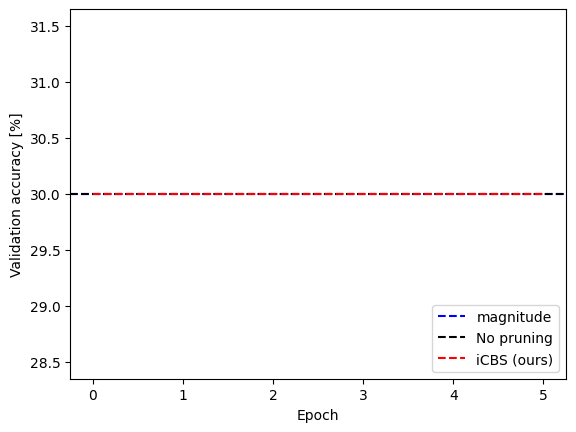

In [12]:
# Plot the evolution of the validation accuracy across epochs
plt.figure()
plt.xlabel("Epoch")
plt.ylabel("Validation accuracy [%]")
plt.axhline(y=valid_accuracies[0], linestyle="--", label=f"{init_method}", color="b")
plt.axhline(y=unpruned_valid_accuracy, linestyle="--", label=f"No pruning", color="k")
plt.plot(valid_accuracies, label="iCBS (ours)", linestyle="--", color="r")
plt.legend(loc="lower right");